# 01 — Dataset Inspection

**Project:** Financial Fraud Detection  
**Step:** 5 — First Dataset Inspection  
**Dataset:** `data/raw/synthetic_fraud_dataset1 (1).csv`

---

## Objective

This notebook performs an initial inspection of the raw financial fraud dataset to understand its structure, data types, missing values, duplicates, target distribution, and basic statistical properties **before any preprocessing or machine learning**.

No data cleaning, feature engineering, encoding, scaling, or model training is performed here. The raw CSV file is loaded in read-only fashion and is never modified.

---
## Section 2 — Import Required Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
%matplotlib inline

---
## Section 3 — Load the Dataset

In [2]:
# Build a robust relative path from the notebooks/ folder to the data file
DATA_PATH = os.path.join("..", "data", "raw", "synthetic_fraud_dataset1 (1).csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully from: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully from: ..\data\raw\synthetic_fraud_dataset1 (1).csv
Shape: 50000 rows × 14 columns


### First 5 rows

In [3]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,7 December 2023,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,11 November 2023,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


### Last 5 rows

In [4]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
49995,TXN_11284,USER_4796,45.05,Online,29 January 2023,76960.11,Mobile,Tokyo,Clothing,0,2,Amex,98,0
49996,TXN_44732,USER_1171,126.15,POS,9 May 2023,28791.75,Mobile,Tokyo,Clothing,0,13,Visa,93,1
49997,TXN_38158,USER_2510,72.02,Online,30 January 2023,29916.41,Laptop,Mumbai,Clothing,1,1,Visa,114,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,9 March 2023,67895.67,Mobile,Tokyo,Electronics,0,13,Discover,72,1
49999,TXN_15795,USER_6529,13.00,Bank Transfer,19 August 2023,7668.82,Tablet,London,Restaurants,0,5,Mastercard,154,1


---
## Section 4 — Dataset Dimensions

In [5]:
num_rows, num_cols = df.shape

print(f"Number of rows   : {num_rows:,}")
print(f"Number of columns: {num_cols}")
print(f"Shape            : {df.shape}")

Number of rows   : 50,000
Number of columns: 14
Shape            : (50000, 14)


---
## Section 5 — Column Names

In [6]:
print("All column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"  {i}. {col}")

All column names:
  1. Transaction_ID
  2. User_ID
  3. Transaction_Amount
  4. Transaction_Type
  5. Date
  6. Account_Balance
  7. Device_Type
  8. Location
  9. Merchant_Category
  10. Previous_Fraudulent_Activity
  11. Daily_Transaction_Count
  12. Card_Type
  13. Card_Age
  14. Fraud_Label


### Column Name — Data Type table

In [7]:
column_type_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})
column_type_table.index = range(1, len(column_type_table) + 1)
column_type_table

,Column Name,Data Type
1,Transaction_ID,object
2,User_ID,object
3,Transaction_Amount,float64
4,Transaction_Type,object
5,Date,object
6,Account_Balance,float64
7,Device_Type,object
8,Location,object
9,Merchant_Category,object
10,Previous_Fraudulent_Activity,int64


---
## Section 6 — Data Types

In [8]:
df.dtypes

Transaction_ID                   object
User_ID                          object
Transaction_Amount              float64
Transaction_Type                 object
Date                             object
Account_Balance                 float64
Device_Type                      object
Location                         object
Merchant_Category                object
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count           int64
Card_Type                        object
Card_Age                          int64
Fraud_Label                       int64
dtype: object

In [9]:
print("Data-type summary:")
print(f"  object  (categorical/text) columns: {df.select_dtypes(include='object').shape[1]}")
print(f"  int64   (integer)          columns: {df.select_dtypes(include='int64').shape[1]}")
print(f"  float64 (decimal)          columns: {df.select_dtypes(include='float64').shape[1]}")

Data-type summary:
  object  (categorical/text) columns: 8
  int64   (integer)          columns: 4
  float64 (decimal)          columns: 2


**Interpretation:**

- **Numerical columns (float64):** `Transaction_Amount`, `Account_Balance` — continuous monetary values.
- **Numerical columns (int64):** `Previous_Fraudulent_Activity`, `Daily_Transaction_Count`, `Card_Age`, `Fraud_Label` — discrete/integer values.
- **Categorical / object columns:** `Transaction_ID`, `User_ID`, `Transaction_Type`, `Date`, `Device_Type`, `Location`, `Merchant_Category`, `Card_Type` — text-based identifiers, categories, and dates.
- **Date-related:** The `Date` column is stored as `object` (string). It would need parsing in a future step.
- **Target column:** `Fraud_Label` (int64, binary: 0 or 1).

*(No data-type conversions are performed in this notebook.)*

---
## Section 7 — Missing Values

In [10]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": missing_count.values,
    "Missing Percentage (%)": missing_pct.values
})
missing_table.index = range(1, len(missing_table) + 1)
missing_table

,Column,Missing Count,Missing Percentage (%)
1,Transaction_ID,0,0.0
2,User_ID,0,0.0
3,Transaction_Amount,0,0.0
4,Transaction_Type,0,0.0
5,Date,0,0.0
6,Account_Balance,0,0.0
7,Device_Type,0,0.0
8,Location,0,0.0
9,Merchant_Category,0,0.0
10,Previous_Fraudulent_Activity,0,0.0


In [11]:
total_missing = df.isnull().sum().sum()
print(f"Total missing values across the entire dataset: {total_missing}")

if total_missing == 0:
    print("\n✅ There are NO missing values in any column.")
else:
    print(f"\n⚠️  The dataset contains {total_missing} missing values. See the table above for details.")

Total missing values across the entire dataset: 0

✅ There are NO missing values in any column.


---
## Section 8 — Duplicate Records

In [12]:
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"Total duplicate rows  : {duplicate_count}")
print(f"Duplicate percentage  : {duplicate_pct:.2f}%")

if duplicate_count == 0:
    print("\n✅ There are NO fully duplicated rows in the dataset.")
else:
    print(f"\n⚠️  {duplicate_count} duplicated rows found. These should be investigated in the preprocessing step.")

Total duplicate rows  : 0
Duplicate percentage  : 0.00%

✅ There are NO fully duplicated rows in the dataset.


---
## Section 9 — Target Variable Inspection

In [13]:
# Verify the target column exists
target_col = "Fraud_Label"

if target_col in df.columns:
    print(f"✅ Target column '{target_col}' exists in the dataset.")
else:
    print(f"❌ Target column '{target_col}' NOT found! Available columns: {list(df.columns)}")

✅ Target column 'Fraud_Label' exists in the dataset.


In [14]:
# Unique values
print(f"Unique values in '{target_col}': {df[target_col].unique()}")
print(f"Number of unique values: {df[target_col].nunique()}")

Unique values in 'Fraud_Label': [0 1]
Number of unique values: 2


In [15]:
# Value counts
print("Value Counts:")
print(df[target_col].value_counts())

print("\nValue Percentages:")
print(df[target_col].value_counts(normalize=True).mul(100).round(2))

Value Counts:
Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Value Percentages:
Fraud_Label
0    67.87
1    32.13
Name: proportion, dtype: float64


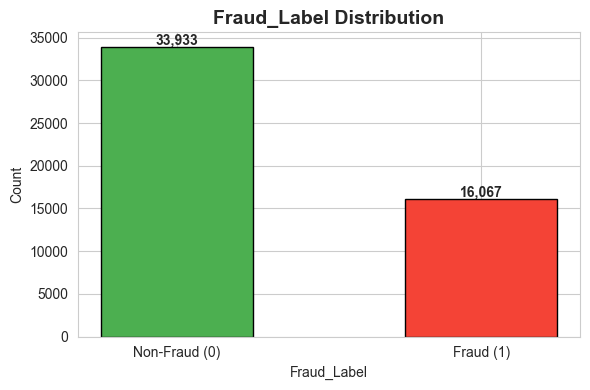

In [16]:
# Visualization — Fraud_Label distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df[target_col].value_counts().sort_index()
labels = ["Non-Fraud (0)", "Fraud (1)"]
colors = ["#4CAF50", "#F44336"]

ax.bar(labels, counts.values, color=colors, edgecolor="black", width=0.5)

for i, val in enumerate(counts.values):
    ax.text(i, val + 300, f"{val:,}", ha="center", fontweight="bold")

ax.set_title("Fraud_Label Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Fraud_Label")
plt.tight_layout()
plt.show()

---
## Section 10 — Numerical Summary

In [17]:
df.describe()

,Transaction_Amount,Account_Balance,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Age,Fraud_Label
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.098400,7.485240,119.999940,0.321340
std,98.687292,28760.458557,0.297858,4.039637,68.985817,0.466996
min,0.000000,500.480000,0.000000,1.000000,1.000000,0.000000
25%,28.677500,25355.995000,0.000000,4.000000,60.000000,0.000000
50%,69.660000,50384.430000,0.000000,7.000000,120.000000,0.000000
75%,138.852500,75115.135000,0.000000,11.000000,180.000000,1.000000
max,1174.140000,99998.310000,1.000000,14.000000,239.000000,1.000000


**Key statistics explained:**

| Statistic | Meaning |
|---|---|
| **count** | Number of non-null values in each column |
| **mean** | Average value |
| **std** | Standard deviation — measures how spread out the values are |
| **min** | Smallest value |
| **25%** | First quartile (25th percentile) |
| **50%** | Median (50th percentile) |
| **75%** | Third quartile (75th percentile) |
| **max** | Largest value |

---
## Section 11 — Categorical Column Inspection

In [18]:
# Identify categorical (object) columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Number of categorical/object columns: {len(cat_cols)}")
print(f"Columns: {cat_cols}")

Number of categorical/object columns: 8
Columns: ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Date', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']


In [19]:
# Unique-value summary for categorical columns
cat_summary = pd.DataFrame({
    "Column": cat_cols,
    "Number of Unique Values": [df[col].nunique() for col in cat_cols]
})
cat_summary.index = range(1, len(cat_summary) + 1)
cat_summary

,Column,Number of Unique Values
1,Transaction_ID,50000
2,User_ID,8963
3,Transaction_Type,4
4,Date,365
5,Device_Type,3
6,Location,5
7,Merchant_Category,5
8,Card_Type,4


In [20]:
# Value counts for low-cardinality categorical columns
low_cardinality_cols = [col for col in cat_cols if df[col].nunique() <= 10]

for col in low_cardinality_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().to_string())


--- Transaction_Type (4 unique values) ---
Transaction_Type
POS               12549
Online            12546
ATM Withdrawal    12453
Bank Transfer     12452

--- Device_Type (3 unique values) ---
Device_Type
Tablet    16779
Mobile    16640
Laptop    16581

--- Location (5 unique values) ---
Location
Tokyo       10208
Mumbai       9994
London       9945
Sydney       9938
New York     9915

--- Merchant_Category (5 unique values) ---
Merchant_Category
Clothing       10033
Groceries      10019
Travel         10015
Restaurants     9976
Electronics     9957

--- Card_Type (4 unique values) ---
Card_Type
Mastercard    12693
Visa          12560
Amex          12419
Discover      12328


---
## Section 12 — Numerical Column Inspection

In [21]:
# Identify numerical columns
num_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Number of numerical columns: {len(num_cols)}")
print(f"Columns: {num_cols}")

Number of numerical columns: 6
Columns: ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Fraud_Label']


In [22]:
# Numerical column summary table
num_summary = pd.DataFrame({
    "Column": num_cols,
    "Unique Values": [df[col].nunique() for col in num_cols],
    "Minimum": [df[col].min() for col in num_cols],
    "Maximum": [df[col].max() for col in num_cols]
})
num_summary.index = range(1, len(num_summary) + 1)
num_summary

,Column,Unique Values,Minimum,Maximum
1,Transaction_Amount,21763,0.00,1174.14
2,Account_Balance,49867,500.48,99998.31
3,Previous_Fraudulent_Activity,2,0.00,1.00
4,Daily_Transaction_Count,14,1.00,14.00
5,Card_Age,239,1.00,239.00
6,Fraud_Label,2,0.00,1.00


---
## Section 13 — Basic Distribution Visualization

A small set of plots to understand key distributions in the raw data.

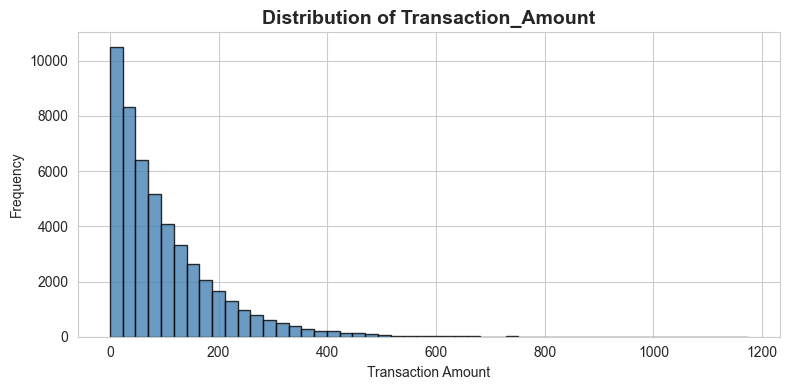

In [23]:
# Plot 1 — Transaction_Amount distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Transaction_Amount"], bins=50, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_title("Distribution of Transaction_Amount", fontsize=14, fontweight="bold")
ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

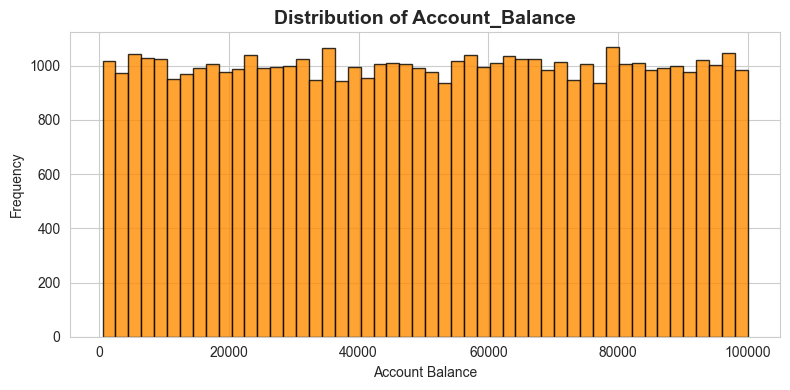

In [24]:
# Plot 2 — Account_Balance distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Account_Balance"], bins=50, color="darkorange", edgecolor="black", alpha=0.8)
ax.set_title("Distribution of Account_Balance", fontsize=14, fontweight="bold")
ax.set_xlabel("Account Balance")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

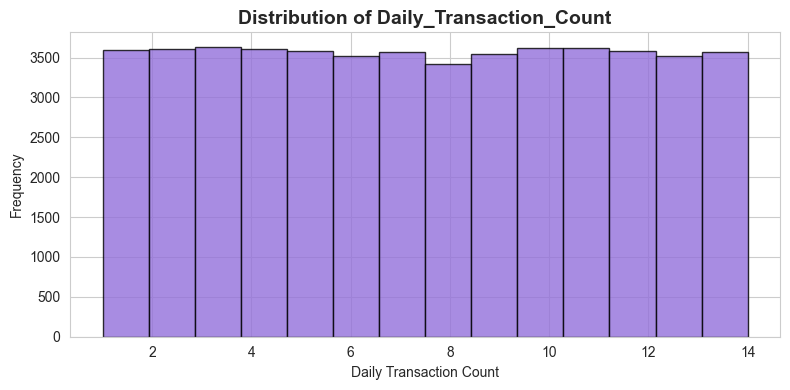

In [25]:
# Plot 3 — Daily_Transaction_Count distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Daily_Transaction_Count"], bins=14, color="mediumpurple", edgecolor="black", alpha=0.8)
ax.set_title("Distribution of Daily_Transaction_Count", fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Transaction Count")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

---
## Section 14 — Initial Observations

Based on the outputs generated above, here is a summary of the raw dataset:

### Dataset Size
- **50,000 rows** and **14 columns**.

### Target Distribution (`Fraud_Label`)
- Binary target: `0` (Non-Fraud) and `1` (Fraud).
- Non-Fraud: **33,933** (67.87%)
- Fraud: **16,067** (32.13%)
- The dataset is **moderately imbalanced** — roughly a 2:1 ratio. This is not extreme but should be considered during model training in a later step.

### Data Types
- **8 object/categorical** columns: `Transaction_ID`, `User_ID`, `Transaction_Type`, `Date`, `Device_Type`, `Location`, `Merchant_Category`, `Card_Type`.
- **4 integer** columns: `Previous_Fraudulent_Activity`, `Daily_Transaction_Count`, `Card_Age`, `Fraud_Label`.
- **2 float** columns: `Transaction_Amount`, `Account_Balance`.

### Missing Values
- **Zero** missing values across all 14 columns.

### Duplicate Records
- **Zero** fully duplicated rows.

### Notable Ranges & Distributions
- `Transaction_Amount`: ranges from **0.00 to 1,174.14** (mean ≈ 99.41); right-skewed with most values concentrated at the lower end.
- `Account_Balance`: ranges from **500.48 to 99,998.31** (mean ≈ 50,294); appears roughly uniform.
- `Daily_Transaction_Count`: ranges from **1 to 14** (mean ≈ 7.49); appears roughly uniform.
- `Card_Age`: ranges from **1 to 239** (mean ≈ 120); appears roughly uniform.
- `Previous_Fraudulent_Activity`: binary (0/1); about 9.84% of transactions are flagged.

### Categorical Columns
- Low-cardinality categories: `Transaction_Type` (4), `Device_Type` (3), `Location` (5), `Merchant_Category` (5), `Card_Type` (4) — all with roughly even value distributions.
- `Transaction_ID` has 50,000 unique values (one per row), confirming it is a unique identifier.
- `User_ID` has 8,963 unique values, meaning some users have multiple transactions.
- `Date` is stored as a string (e.g., "14 August 2023") with 365 unique values spanning one year.

### Items to Investigate in the Next Step
- The `Date` column is currently stored as a string and will need to be parsed into a proper datetime type.
- `Transaction_ID` and `User_ID` are identifiers and typically would not be used as model features; their role should be decided during preprocessing.
- The near-uniform distribution of several categorical columns is worth noting — it may indicate this is a synthetically generated dataset.
- The right skew in `Transaction_Amount` may warrant investigation for outliers during preprocessing.

---
## Section 15 — Next Step

The next project step will be **data cleaning / preprocessing and feature engineering**.

This may include:
- Parsing the `Date` column into datetime format
- Deciding how to handle identifier columns (`Transaction_ID`, `User_ID`)
- Encoding categorical variables
- Scaling/normalizing numerical features
- Addressing class imbalance

**Those steps are NOT implemented in this notebook.** This notebook is strictly for raw dataset inspection.